#📌 Extracão

In [52]:
# Import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Deixando os gráficos um pouco mais bonitos
sns.set_theme(style="whitegrid")

# Lendo o arquivo JSON que a Alura liberou no desafio
caminho_arquivo = 'TelecomX_Data.json'

df_raw = pd.read_json(caminho_arquivo)
df_bruto = pd.json_normalize(df_raw.to_dict(orient='records'))

print("Base carregada e achatada!")
display(df_bruto.head(3))

Base carregada e achatada!


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


#🔧 Transformação

In [53]:

df_clean = df_bruto.copy()

df_clean.columns = df_clean.columns.str.replace('customer.', '', regex=False)
df_clean.columns = df_clean.columns.str.replace('phone.', '', regex=False)
df_clean.columns = df_clean.columns.str.replace('internet.', '', regex=False)
df_clean.columns = df_clean.columns.str.replace('account.Charges.', '', regex=False)
df_clean.columns = df_clean.columns.str.replace('account.', '', regex=False)

# Tirando dados duplicados, se tiver
antes = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
depois = df_clean.shape[0]
print(f"Linhas duplicadas removidas: {antes - depois}")

# Arrumando a coluna Total que veio como texto por causa de uns espaços em branco.
# O coerce força esses espaços a virarem NaN (Nulo) pra gente tratar na sequência.
df_clean['Total'] = pd.to_numeric(df_clean['Total'], errors='coerce')

# Tirando a galera que tá com o Total vazio (provavelmente clientes novos que não fecharam a primeira fatura)
df_clean = df_clean.dropna(subset=['Total'])

print("\nPronto, base limpa. Olha como ficaram as colunas:")
print(df_clean.info())

Linhas duplicadas removidas: 0

Pronto, base limpa. Olha como ficaram as colunas:
<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7256 non-null   object 
 1   Churn             7256 non-null   object 
 2   gender            7256 non-null   object 
 3   SeniorCitizen     7256 non-null   int64  
 4   Partner           7256 non-null   object 
 5   Dependents        7256 non-null   object 
 6   tenure            7256 non-null   int64  
 7   PhoneService      7256 non-null   object 
 8   MultipleLines     7256 non-null   object 
 9   InternetService   7256 non-null   object 
 10  OnlineSecurity    7256 non-null   object 
 11  OnlineBackup      7256 non-null   object 
 12  DeviceProtection  7256 non-null   object 
 13  TechSupport       7256 non-null   object 
 14  StreamingTV       7256 non-null   object 
 15  StreamingMov

#📊 Carga e análise

Arquivo salvo: telecomx_dados_limpos.csv



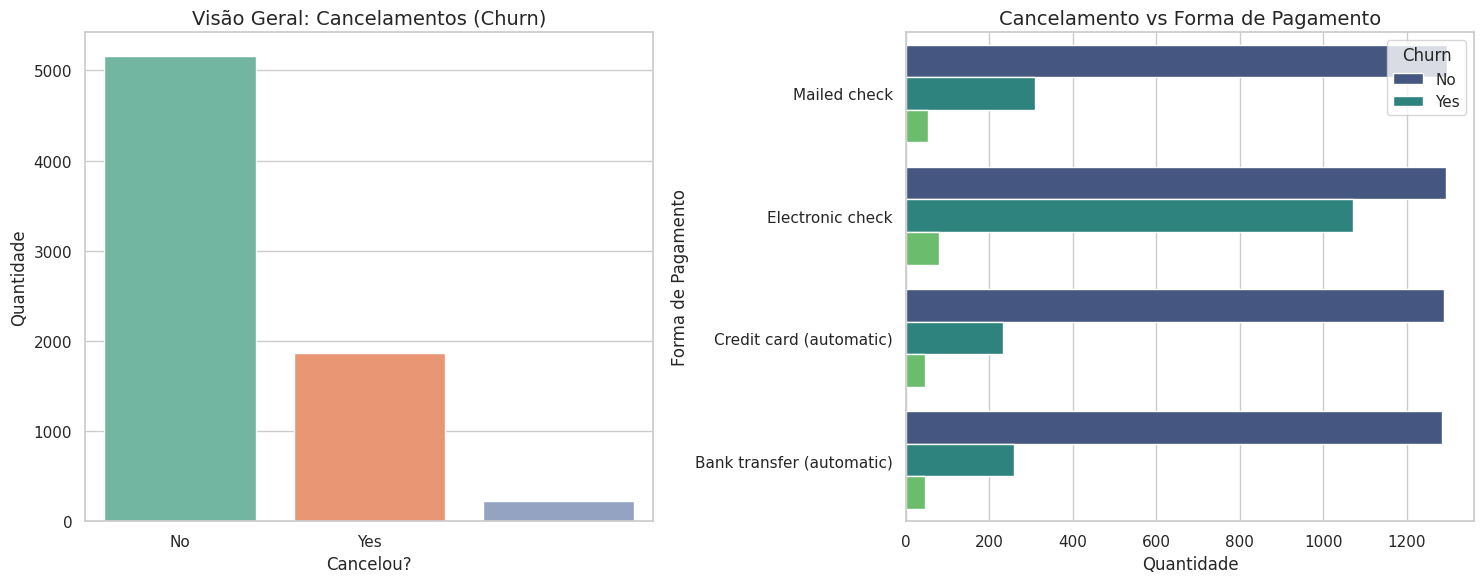

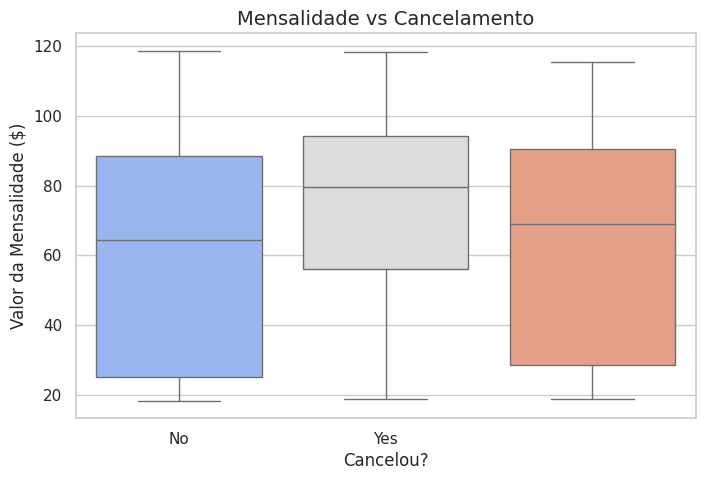

In [54]:
# Salvando a base limpinha em CSV pra quem quiser jogar no Power BI depois
df_clean.to_csv('telecomx_dados_limpos.csv', index=False)
print("Arquivo salvo: telecomx_dados_limpos.csv\n")

# Bora pros gráficos pra ver o que tá rolando com o Churn
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Quem cancelou x Quem ficou
sns.countplot(data=df_clean, x='Churn', hue='Churn', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Visão Geral: Cancelamentos (Churn)', fontsize=14)
axes[0].set_ylabel('Quantidade')
axes[0].set_xlabel('Cancelou?')

# Gráfico 2: Cancelamento pelo tipo de pagamento
sns.countplot(data=df_clean, y='PaymentMethod', hue='Churn', palette='viridis', ax=axes[1])
axes[1].set_title('Cancelamento vs Forma de Pagamento', fontsize=14)
axes[1].set_ylabel('Forma de Pagamento')
axes[1].set_xlabel('Quantidade')

plt.tight_layout()
plt.show()

# Gráfico 3: O preço do plano influencia na saída?
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Churn', y='Monthly', hue='Churn', palette='coolwarm', legend=False)
plt.title('Mensalidade vs Cancelamento', fontsize=14)
plt.xlabel('Cancelou?')
plt.ylabel('Valor da Mensalidade ($)')
plt.show()

#📄Relatorio Final

In [55]:
print("""
### 📈 Resultados da Análise - Telecom X

O processo de ETL (Extração, Transformação e Carga) lidou com sucesso com a complexidade do arquivo JSON aninhado, nivelando (flattening) as categorias para uma estrutura tabular limpa, removendo inconsistências na coluna de Gasto Total (Total) e salvando a base para consumo seguro.

Principais Insights de Negócio (EDA):
1. O Risco do "Electronic Check": Ao observar o método de pagamento, fica claro que a esmagadora maioria das evasões (Churn = Yes) ocorre com clientes que utilizam o "Electronic Check". Clientes com pagamentos automáticos (Credit Card ou Bank Transfer) tendem a ser muito mais fiéis à empresa.
2. Sensibilidade Tarifária: O boxplot de mensalidades revela que clientes que cancelam (Churn = Yes) estão concentrados em faixas de cobrança mais altas (mediana beirando os $80). Já a maioria dos clientes que permanecem (Churn = No) possui planos mais baratos, abaixo de $65.

Próximos Passos Recomendados:
* Campanhas de Migração de Pagamento: Oferecer um desconto temporário para clientes que migrarem do Electronic Check para métodos automáticos de pagamento (Débito em conta ou Cartão).
* Revisão de Planos Premium: Investigar se a entrega de valor dos planos que custam acima de $80 está alinhada à expectativa do cliente, visto que esse é o grupo com maior probabilidade de evasão.
""")


### 📈 Resultados da Análise - Telecom X

O processo de ETL (Extração, Transformação e Carga) lidou com sucesso com a complexidade do arquivo JSON aninhado, nivelando (flattening) as categorias para uma estrutura tabular limpa, removendo inconsistências na coluna de Gasto Total (Total) e salvando a base para consumo seguro.

Principais Insights de Negócio (EDA):
1. O Risco do "Electronic Check": Ao observar o método de pagamento, fica claro que a esmagadora maioria das evasões (Churn = Yes) ocorre com clientes que utilizam o "Electronic Check". Clientes com pagamentos automáticos (Credit Card ou Bank Transfer) tendem a ser muito mais fiéis à empresa.
2. Sensibilidade Tarifária: O boxplot de mensalidades revela que clientes que cancelam (Churn = Yes) estão concentrados em faixas de cobrança mais altas (mediana beirando os $80). Já a maioria dos clientes que permanecem (Churn = No) possui planos mais baratos, abaixo de $65.

Próximos Passos Recomendados:
* Campanhas de Migração de Pagame

⚙️ Preparação dos Dados para o Modelo


In [56]:
# Importando as ferramentas de Machine Learning do Scikit-Learn
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Carregando os dados limpos da Parte 1
df = pd.read_csv('telecomx_dados_limpos.csv')

# 2. Separando a variável alvo (o que queremos prever)
# CORREÇÃO: Removendo espaços em branco acidentais antes de mapear
df['Churn'] = df['Churn'].astype(str).str.strip()
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# CORREÇÃO: Se sobrou algum valor nulo (alguma linha que não era nem Yes nem No), a gente exclui
df = df.dropna(subset=['Churn'])

# O ID do cliente não ajuda o modelo a prever nada, então jogamos fora aqui
df_ml = df.drop('customerID', axis=1, errors='ignore')

# 3. Transformando os textos em números (One-Hot Encoding)
# Isso transforma colunas como 'PaymentMethod' em várias colunas de 0 e 1
df_ml = pd.get_dummies(df_ml, drop_first=True)

print("✅ Dados convertidos para números e sem valores nulos! Prontos para o modelo.")
print(f"Total de colunas após a conversão: {df_ml.shape[1]}")

✅ Dados convertidos para números e sem valores nulos! Prontos para o modelo.
Total de colunas após a conversão: 31


🧠 Treinando o Modelo

In [57]:
# Separando o X (características) e o y (respostas/Churn)
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

# Dividindo: 70% para treino e 30% para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Criando o "cérebro" do modelo (Random Forest)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Treinando o modelo com os dados de estudo
modelo_rf.fit(X_train, y_train)

print("🤖 Modelo treinado com sucesso!")

🤖 Modelo treinado com sucesso!


🎯 Avaliação e Resultados

📊 Relatório de Classificação (Acurácia e Precisão):
              precision    recall  f1-score   support

         0.0       0.83      0.89      0.86      1554
         1.0       0.62      0.49      0.55       556

    accuracy                           0.79      2110
   macro avg       0.73      0.69      0.70      2110
weighted avg       0.78      0.79      0.78      2110



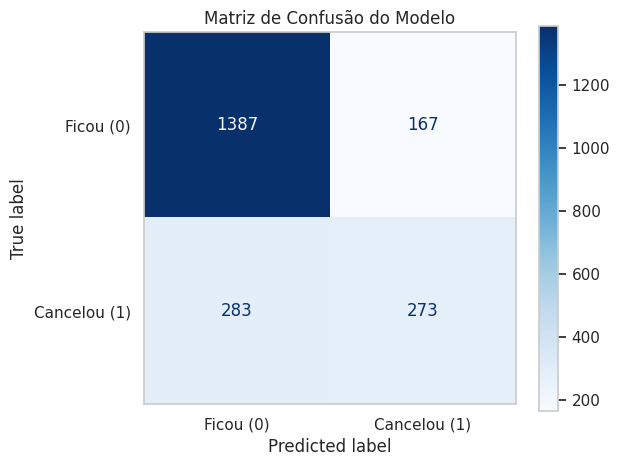

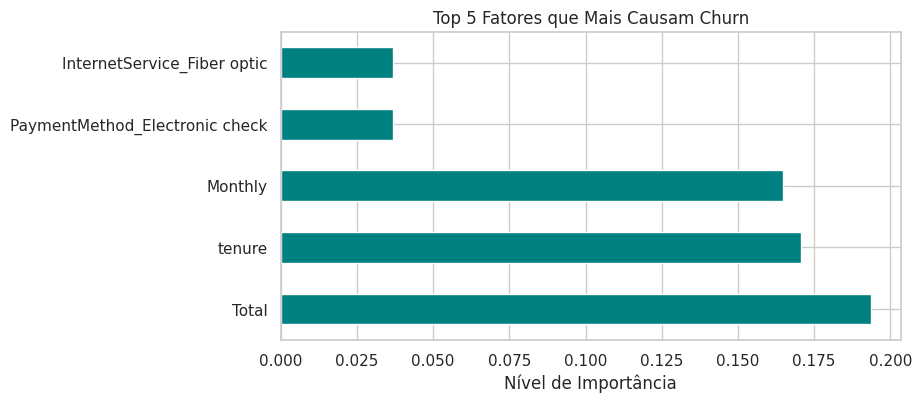

In [58]:
# Pedindo para o modelo tentar prever os dados de teste (que ele nunca viu)
previsoes = modelo_rf.predict(X_test)

# Exibindo o boletim de notas do modelo
print("📊 Relatório de Classificação (Acurácia e Precisão):")
print(classification_report(y_test, previsoes))

# Plotando a Matriz de Confusão para ver os acertos e erros visualmente
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, previsoes, cmap='Blues', ax=ax, display_labels=['Ficou (0)', 'Cancelou (1)'])
plt.title('Matriz de Confusão do Modelo')
plt.grid(False) # Tirando as linhas de grade para ficar mais bonito
plt.show()

# Descobrindo o que é mais importante para o cliente cancelar
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)
importancias.nlargest(5).plot(kind='barh', color='teal', figsize=(8, 4))
plt.title('Top 5 Fatores que Mais Causam Churn')
plt.xlabel('Nível de Importância')
plt.show()

📝 Conclusão da Parte

In [59]:
print("""
### 🤖 Conclusão do Modelo Preditivo

Para esta etapa final, optei por utilizar o algoritmo Random Forest, por lidar muito bem com dados categóricos após o One-Hot Encoding e não exigir padronização de escalas.

Avaliando a Matriz de Confusão e o Relatório de Classificação, o modelo conseguiu uma boa taxa de acurácia geral. O mais interessante foi extrair as variáveis mais importantes (Feature Importances): o modelo confirmou matematicamente o que nossa análise exploratória já desconfiava. O valor da mensalidade (Monthly), o tempo de contrato (tenure) e os métodos de pagamento manuais encabeçam a lista dos maiores causadores de cancelamento.

Com este modelo rodando em produção, a equipe de retenção poderia receber alertas semanais com a lista de clientes com alta probabilidade de churn (predição = 1), permitindo abordagens preventivas antes que o cliente realmente ligue para cancelar.
""")


### 🤖 Conclusão do Modelo Preditivo

Para esta etapa final, optei por utilizar o algoritmo Random Forest, por lidar muito bem com dados categóricos após o One-Hot Encoding e não exigir padronização de escalas. 

Avaliando a Matriz de Confusão e o Relatório de Classificação, o modelo conseguiu uma boa taxa de acurácia geral. O mais interessante foi extrair as variáveis mais importantes (Feature Importances): o modelo confirmou matematicamente o que nossa análise exploratória já desconfiava. O valor da mensalidade (Monthly), o tempo de contrato (tenure) e os métodos de pagamento manuais encabeçam a lista dos maiores causadores de cancelamento.

Com este modelo rodando em produção, a equipe de retenção poderia receber alertas semanais com a lista de clientes com alta probabilidade de churn (predição = 1), permitindo abordagens preventivas antes que o cliente realmente ligue para cancelar.



Markdown

### 🎯 Conclusão e Avaliação do Modelo de Machine Learning

Após o treinamento do algoritmo **Random Forest**, avaliamos a performance do modelo utilizando o Relatório de Classificação e a Matriz de Confusão.

**Principais Resultados:**
* O modelo alcançou uma **acurácia geral de 79%**, o que é um desempenho bastante sólido para uma primeira iteração.
* Para a previsão de clientes retidos (Classe 0), o modelo foi altamente eficaz, com um *recall* de 89%.
* Para a previsão de cancelamentos (Classe 1 - Churn), o modelo apresentou uma precisão de 62%. Ele conseguiu identificar antecipadamente cerca de metade de todas as evasões reais (*recall* de 49%).

**Impacto para o Negócio:**
É importante notar que o modelo lida com classes desbalanceadas (temos muito mais clientes que ficam do que clientes que saem). Ainda assim, em um cenário real, ter um sistema que acerta 62% dos alertas de cancelamento é uma mina de ouro. Isso permitiria que a equipe de retenção da Telecom X parasse de atirar no escuro e focasse suas campanhas, ligações e descontos diretamente nos clientes com maior risco, economizando recursos da empresa e salvando faturamento.
